In [8]:
!pip install torchmetrics
!pip install gradio

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

from tqdm import tqdm
import gradio as gr

In [12]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
print(torch.cuda.get_device_name(0))

Tesla T4


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dir = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/train"

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4,pin_memory=True)

In [14]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

val_dir = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/val/images"

class ValImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.filenames = os.listdir(img_dir)
        self.transform = transform
        
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.img_dir, fname)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

val_dataset = ValImageDataset(val_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4,pin_memory=True)

In [15]:
def patchify(imgs,patch_size=16):
    p=patch_size
    B,C,H,W=imgs.shape
    patches=imgs.unfold(2,p,p).unfold(3,p,p)#makes 224x224 to 16x16 shaped -14x14(196) patches
    patches=patches.contiguous().view(B,C,-1,p,p)#merges 14,14 to 196
    patches=patches.permute(0,2,1,3,4)#rearrange dimensions
    patches=patches.flatten(2)#flatten input is start dim so now 3x16x16=768 vector patch
    return patches



In [16]:
dummy = torch.randn(2,3,224,224)

patches = patchify(dummy)

print(patches.shape)

torch.Size([2, 196, 768])


In [17]:
def randomMasking(x, mask_ratio=0.75):
    device = x.device 
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio)) 

    noise = torch.rand(B, N, device=device)  
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]

    x_masked = torch.gather(
        x, 1, ids_keep.unsqueeze(-1).repeat(1, 1, D).to(device)
    )

    return x_masked, ids_restore.to(device)

In [18]:
class TransformerBlock(nn.Module):
    def __init__(self,dim,heads):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim,dim*4),
            nn.GELU(),
            nn.Linear(dim*4,dim)
        )

    def forward(self,x):
        x=x+self.attn(self.norm1(x),
                      self.norm1(x),
                      self.norm1(x))[0]
        x=x+self.mlp(self.norm2(x))

        return x

In [20]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Linear(768,768)
        self.pos_embed = nn.Parameter(
            torch.randn(1,196,768)
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(768,12)
            for _ in range(12)
        ])
        self.norm = nn.LayerNorm(768)

    def forward(self,x):
        x=self.patch_embed(x)
        x=x+self.pos_embed[:,:x.shape[1]]
        for blk in self.blocks:
            x=blk(x)
        x=self.norm(x)
        return x
    
    
    

In [21]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.mask_token = nn.Parameter(torch.randn(1, 1, 384))
        self.pos_embed = nn.Parameter(torch.randn(1, 196, 384))  
        self.blocks = nn.ModuleList([
            TransformerBlock(384, 6)
            for _ in range(12)
        ])
        self.norm = nn.LayerNorm(384)
        self.head = nn.Linear(384, 768)

    def forward(self, x):
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = self.head(x)
        return x

In [22]:
class MAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.enc_to_dec = nn.Linear(768, 384)
        self.decoder = Decoder()

    def forward(self, x, mask_ratio=0.75):
        device = x.device
        patches = patchify(x).to(device)

        tokens = self.encoder.patch_embed(patches)
        tokens = tokens + self.encoder.pos_embed         
        visible, ids_restore = randomMasking(tokens, mask_ratio)

        for blk in self.encoder.blocks:
            visible = blk(visible)
        latent = self.encoder.norm(visible)

        latent = self.enc_to_dec(latent)                 
        B, N_vis, D = latent.shape
        N = ids_restore.shape[1]

        mask_tokens = self.decoder.mask_token.repeat(B, N - N_vis, 1).to(device)
        x_ = torch.cat([latent, mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, D))

        pred = self.decoder(x_)
        return pred, patches, ids_restore                

In [25]:
epoch=10
batch_size=32
learning_rate=1e-4
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir,exist_ok=True)

In [26]:
from torch.optim.lr_scheduler import CosineAnnealingLR
model = MAE().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.05
)
criterion = nn.MSELoss()

# Example: total epochs = num_epochs
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

In [27]:
import os

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "mae_checkpoint.pth")

start_epoch = 0
if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming training from epoch {start_epoch}")

Loading checkpoint...
Resuming training from epoch 9


In [ ]:
from torch.amp import autocast, GradScaler

scaler = GradScaler()
num_epochs = 10  # changeable; resumes from checkpoint

from tqdm import tqdm

train_losses = []  # collect per-epoch loss for plotting

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0

    for batch_idx, (images, _) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        images = images.to(device)
        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            pred, patches, ids_restore = model(images, mask_ratio=0.75)

            B, N, D = patches.shape
            num_visible = int(N * 0.25)

            # Build mask: 0 for visible, 1 for masked
            mask = torch.ones(B, N, D, device=device)
            vis_idx = ids_restore[:, :num_visible]
            mask.scatter_(1, vis_idx.unsqueeze(-1).expand(-1, -1, D), 0)

            loss = ((pred - patches) ** 2 * mask).sum() / mask.sum()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f}", flush=True)

    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'train_losses': train_losses,
    }, checkpoint_path)


In [ ]:
import matplotlib.pyplot as plt

# ── Loss curve ────────────────────────────────────────────────────────────────
# Also works if you load losses from a saved checkpoint:
# ckpt = torch.load(checkpoint_path, map_location='cpu')
# train_losses = ckpt['train_losses']

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linewidth=2,
         color='#7c6bf7', markersize=6, markerfacecolor='#4fd1c5', markeredgewidth=0)
plt.fill_between(range(1, len(train_losses) + 1), train_losses, alpha=0.15, color='#7c6bf7')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss (masked patches)", fontsize=12)
plt.title("MAE Training Loss", fontsize=14, fontweight='bold')
plt.xticks(range(1, len(train_losses) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
batch = next(iter(val_loader))
print(len(batch))  # How many items per batch?

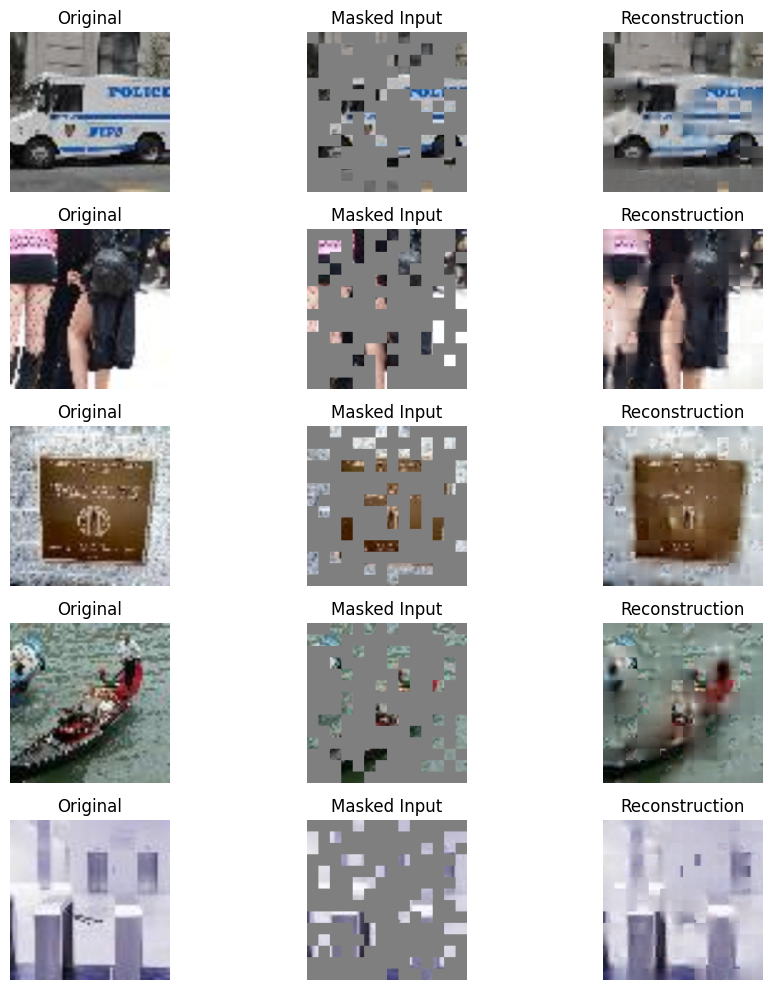

In [29]:
import matplotlib.pyplot as plt
import torch

model.eval()

def unpatchify(patches, img_size=224, patch_size=16):
    B, N, D = patches.shape
    h = w = img_size // patch_size
    patches = patches.reshape(B, h, w, 3, patch_size, patch_size)
    patches = patches.permute(0, 3, 1, 4, 2, 5)
    imgs = patches.reshape(B, 3, img_size, img_size)
    return imgs

num_samples = 5
with torch.no_grad():
    for batch in val_loader:
        images = batch.to(device)

        pred, patches, ids_restore = model(images, mask_ratio=0.75)  # unpack 3 values

        B, N, D = patches.shape
        num_visible = int(N * 0.25)
        masked_indices = ids_restore[:, num_visible:]   # indices of masked patches

        # Masked input: fill masked patch positions with gray (0.5)
        masked_patches = patches.clone()
        masked_patches.scatter_(1, masked_indices.unsqueeze(-1).expand(-1, -1, D), 0.5)
        masked_input_img = unpatchify(masked_patches)

        # Reconstruction: keep original visible patches, fill masked positions with model predictions
        composite_patches = patches.clone()
        composite_patches.scatter_(
            1,
            masked_indices.unsqueeze(-1).expand(-1, -1, D),
            torch.gather(pred, 1, masked_indices.unsqueeze(-1).expand(-1, -1, D))
        )
        recon_imgs = unpatchify(composite_patches)

        fig, axes = plt.subplots(num_samples, 3, figsize=(10, 10))
        for j in range(num_samples):
            axes[j, 0].imshow(images[j].permute(1,2,0).cpu().clamp(0,1))
            axes[j, 0].set_title("Original")

            axes[j, 1].imshow(masked_input_img[j].permute(1,2,0).cpu().clamp(0,1))
            axes[j, 1].set_title("Masked Input")

            axes[j, 2].imshow(recon_imgs[j].permute(1,2,0).cpu().clamp(0,1))
            axes[j, 2].set_title("Reconstruction")

            for k in range(3):
                axes[j, k].axis('off')
        plt.tight_layout()
        plt.show()
        break


In [31]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

model.eval()
psnr_list, ssim_list = [], []

with torch.no_grad():
    for batch in val_loader:
        images = batch.to(device)
        pred, patches, ids_restore = model(images)  # unpack 3 values

        B, N, D = patches.shape
        num_visible = int(N * 0.25)
        masked_indices = ids_restore[:, num_visible:]

        composite_patches = patches.clone()
        composite_patches.scatter_(
            1,
            masked_indices.unsqueeze(-1).expand(-1, -1, D),
            torch.gather(pred, 1, masked_indices.unsqueeze(-1).expand(-1, -1, D))
        )
        recon_imgs = unpatchify(composite_patches)

        recon_imgs_np = recon_imgs.permute(0,2,3,1).clamp(0,1).cpu().numpy()
        images_np = images.permute(0,2,3,1).cpu().numpy()

        for j in range(images.shape[0]):
            psnr_list.append(psnr(images_np[j], recon_imgs_np[j], data_range=1.0))
            ssim_list.append(ssim(images_np[j], recon_imgs_np[j], channel_axis=-1, data_range=1.0))

print(f"Average PSNR: {sum(psnr_list)/len(psnr_list):.2f}")
print(f"Average SSIM: {sum(ssim_list)/len(ssim_list):.4f}")

Average PSNR: 21.56
Average SSIM: 0.6654


In [32]:
torch.save(model.state_dict(), "mae_final.pth")
print("Final model saved!")

Final model saved!


In [ ]:
import gradio as gr
import torchvision.transforms as T
import numpy as np
import time
import torch
from PIL import Image, ImageDraw

_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])

# ── Inference returns (masked_np, recon_np, stats_html, patch_html) ──────────
def reconstruct_image(img, mask_ratio):
    if img is None:
        return None, None, "", ""

    t0 = time.time()
    img_tensor = _transform(img).unsqueeze(0).to(device)
    model.eval()

    with torch.no_grad():
        pred, patches, ids_restore = model(img_tensor, mask_ratio=mask_ratio)

    B, N, D    = patches.shape
    num_vis    = int(N * (1 - mask_ratio))
    mask_idx   = ids_restore[:, num_vis:]
    vis_idx    = ids_restore[:, :num_vis]

    # Masked input (gray fill)
    mp = patches.clone()
    mp.scatter_(1, mask_idx.unsqueeze(-1).expand(-1, -1, D), 0.5)
    masked_np = unpatchify(mp)[0].permute(1, 2, 0).clamp(0, 1).cpu().numpy()

    # Composite reconstruction
    cp = patches.clone()
    cp.scatter_(
        1,
        mask_idx.unsqueeze(-1).expand(-1, -1, D),
        torch.gather(pred, 1, mask_idx.unsqueeze(-1).expand(-1, -1, D))
    )
    recon_np = unpatchify(cp)[0].permute(1, 2, 0).clamp(0, 1).cpu().numpy()

    elapsed = time.time() - t0

    # ── Stats HTML ────────────────────────────────────────────────────────────
    stats_html = f"""
    <div style="display:flex;flex-wrap:wrap;gap:10px;margin:6px 0 2px 0;font-family:'Inter',sans-serif;">
      <div style="flex:1;min-width:110px;background:linear-gradient(135deg,#1a1040,#0d1f3c);
                  border:1px solid #2a2f4a;border-radius:12px;padding:12px 16px;text-align:center;">
        <div style="font-size:1.5rem;font-weight:800;color:#4fd1c5;">{num_vis}</div>
        <div style="font-size:0.68rem;color:#718096;letter-spacing:.07em;text-transform:uppercase;margin-top:2px;">Visible Patches</div>
      </div>
      <div style="flex:1;min-width:110px;background:linear-gradient(135deg,#1a1040,#0d1f3c);
                  border:1px solid #2a2f4a;border-radius:12px;padding:12px 16px;text-align:center;">
        <div style="font-size:1.5rem;font-weight:800;color:#f687b3;">{N - num_vis}</div>
        <div style="font-size:0.68rem;color:#718096;letter-spacing:.07em;text-transform:uppercase;margin-top:2px;">Reconstructed</div>
      </div>
      <div style="flex:1;min-width:110px;background:linear-gradient(135deg,#1a1040,#0d1f3c);
                  border:1px solid #2a2f4a;border-radius:12px;padding:12px 16px;text-align:center;">
        <div style="font-size:1.5rem;font-weight:800;color:#a78bfa;">{int(mask_ratio*100)}%</div>
        <div style="font-size:0.68rem;color:#718096;letter-spacing:.07em;text-transform:uppercase;margin-top:2px;">Mask Ratio</div>
      </div>
      <div style="flex:1;min-width:110px;background:linear-gradient(135deg,#1a1040,#0d1f3c);
                  border:1px solid #2a2f4a;border-radius:12px;padding:12px 16px;text-align:center;">
        <div style="font-size:1.5rem;font-weight:800;color:#f6ad55;">{elapsed:.2f}s</div>
        <div style="font-size:0.68rem;color:#718096;letter-spacing:.07em;text-transform:uppercase;margin-top:2px;">Inference Time</div>
      </div>
    </div>"""

    # ── Patch grid HTML (14×14) ───────────────────────────────────────────────
    mask_bool = torch.ones(N, dtype=torch.bool)
    mask_bool[vis_idx[0].cpu()] = False
    grid = mask_bool.reshape(14, 14).numpy()
    rows = ""
    for row in grid:
        cells = "".join(
            f'<div style="width:13px;height:13px;border-radius:2px;'
            f'background:{"#2d3748" if m else "#4fd1c5"};'
            f'box-shadow:{"none" if m else "0 0 4px rgba(79,209,197,0.5)"};"></div>'
            for m in row
        )
        rows += f'<div style="display:flex;gap:2px;margin-bottom:2px;">{cells}</div>'

    patch_html = f"""
    <div style="background:linear-gradient(135deg,#151929,#1b1f33);border:1px solid #2a2f4a;
                border-radius:14px;padding:16px 18px;font-family:'Inter',sans-serif;">
      <div style="font-size:0.72rem;font-weight:600;letter-spacing:.1em;text-transform:uppercase;
                  color:#718096;margin-bottom:10px;">
        Patch Visibility Map &nbsp;
        <span style="color:#4fd1c5;">■</span> visible &nbsp;
        <span style="color:#4a5568;border:1px solid #4a5568;">■</span> masked
      </div>
      {rows}
    </div>"""

    return masked_np, recon_np, stats_html, patch_html


# ── Custom CSS & JS ───────────────────────────────────────────────────────────
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700;900&display=swap');

* { font-family: 'Inter', sans-serif !important; box-sizing: border-box; }

body, .gradio-container {
    background: #0d0f1a !important;
    color: #e2e8f0 !important;
}

.gradio-container { max-width: 1200px !important; margin: 0 auto !important; padding: 0 16px !important; }

/* ── Hide default header/footer ── */
footer { display: none !important; }
.svelte-1gfkn6j { display: none !important; }

/* ── Panels ── */
.gr-panel, .gr-box, .gr-form, .gr-input-label, .block {
    background: #151929 !important;
    border: 1px solid #2a2f4a !important;
    border-radius: 14px !important;
    color: #e2e8f0 !important;
}

/* ── Labels ── */
label span, .block label span, .svelte-byAclL {
    color: #a0aec0 !important;
    font-size: 0.8rem !important;
    text-transform: uppercase !important;
    letter-spacing: 0.07em !important;
}

/* ── Slider ── */
input[type=range] { accent-color: #7c6bf7 !important; }

/* ── Button ── */
button.primary, .gr-button-primary {
    background: linear-gradient(135deg, #7c6bf7, #4fd1c5) !important;
    border: none !important;
    border-radius: 10px !important;
    color: white !important;
    font-weight: 700 !important;
    font-size: 1rem !important;
    padding: 14px 28px !important;
    cursor: pointer !important;
    transition: opacity 0.2s, transform 0.1s !important;
    box-shadow: 0 0 24px rgba(124,107,247,0.4) !important;
}
button.primary:hover { opacity: 0.88 !important; transform: scale(1.02) !important; }

/* ── Image outputs ── */
.output-image img, .input-image img {
    border-radius: 12px !important;
    border: 1px solid #2a2f4a !important;
}

/* ── Upload zone ── */
.upload-container, [data-testid="image"], .gr-image {
    background: #151929 !important;
    border: 2px dashed #2a2f4a !important;
    border-radius: 14px !important;
    transition: border-color 0.2s !important;
}
.upload-container:hover { border-color: #7c6bf7 !important; }

/* scrollbar */
::-webkit-scrollbar { width: 6px; }
::-webkit-scrollbar-track { background: #0d0f1a; }
::-webkit-scrollbar-thumb { background: #2a2f4a; border-radius: 4px; }
"""

# ── Hero HTML ─────────────────────────────────────────────────────────────────
HERO = """
<div style="background:linear-gradient(135deg,#1a1040 0%,#0d1f3c 55%,#10293f 100%);
            border:1px solid #2a2f4a;border-radius:20px;padding:36px 40px 28px;
            margin-bottom:4px;position:relative;overflow:hidden;font-family:'Inter',sans-serif;">
  <!-- glow blobs -->
  <div style="position:absolute;top:-60px;right:-60px;width:280px;height:280px;
              background:radial-gradient(circle,rgba(124,107,247,.18) 0%,transparent 70%);pointer-events:none;"></div>
  <div style="position:absolute;bottom:-80px;left:-40px;width:260px;height:260px;
              background:radial-gradient(circle,rgba(79,209,197,.12) 0%,transparent 70%);pointer-events:none;"></div>
  <div style="margin-bottom:12px;">
    <span style="background:rgba(124,107,247,.18);border:1px solid rgba(124,107,247,.4);
                 color:#a78bfa;font-size:.7rem;font-weight:700;letter-spacing:.1em;
                 text-transform:uppercase;padding:4px 12px;border-radius:999px;">
      🧠 Vision Transformer · Self-Supervised Learning
    </span>
  </div>
  <h1 style="font-size:2.4rem;font-weight:900;margin:0 0 10px;
             background:linear-gradient(90deg,#a78bfa,#7c6bf7,#4fd1c5);
             -webkit-background-clip:text;-webkit-text-fill-color:transparent;line-height:1.1;">
    Masked Autoencoder
  </h1>
  <p style="color:#718096;font-size:1rem;margin:0;max-width:560px;line-height:1.65;">
    Upload any image — the encoder sees only a fraction of patches and the
    decoder reconstructs the full scene. Drag the mask ratio to make the task harder.
  </p>
  <div style="display:flex;gap:20px;margin-top:20px;flex-wrap:wrap;">
    <div style="display:flex;align-items:center;gap:6px;color:#4fd1c5;font-size:.82rem;">
      <span>⚡</span> 12-layer ViT Encoder
    </div>
    <div style="display:flex;align-items:center;gap:6px;color:#a78bfa;font-size:.82rem;">
      <span>🎭</span> 12-layer Transformer Decoder
    </div>
    <div style="display:flex;align-items:center;gap:6px;color:#f6ad55;font-size:.82rem;">
      <span>🧩</span> 196 patches · 16×16 px each
    </div>
    <div style="display:flex;align-items:center;gap:6px;color:#f687b3;font-size:.82rem;">
      <span>🏋️</span> Trained on Tiny ImageNet 200
    </div>
  </div>
</div>"""

SECTION_MASKED  = '<p style="font-family:Inter,sans-serif;font-size:.75rem;font-weight:700;letter-spacing:.1em;text-transform:uppercase;color:#f6ad55;margin:6px 0 2px;">🎭 Masked Input</p>'
SECTION_RECON   = '<p style="font-family:Inter,sans-serif;font-size:.75rem;font-weight:700;letter-spacing:.1em;text-transform:uppercase;color:#a78bfa;margin:6px 0 2px;">✨ Reconstruction</p>'

# ── Build Gradio Blocks ───────────────────────────────────────────────────────
with gr.Blocks(css=custom_css, title="MAE · Masked Autoencoder") as demo:

    gr.HTML(HERO)

    with gr.Row():
        # ── Left column: controls ──────────────────────────────────────────
        with gr.Column(scale=1):
            gr.HTML('<p style="font-family:Inter,sans-serif;font-size:.75rem;font-weight:700;'
                    'letter-spacing:.1em;text-transform:uppercase;color:#4fd1c5;margin:6px 0 4px;">🖼 Upload Image</p>')
            img_input = gr.Image(type="pil", label="", height=250)

            mask_slider = gr.Slider(
                minimum=0.10, maximum=0.90, value=0.75, step=0.05,
                label="Mask Ratio  —  fraction of patches hidden from the encoder",
            )

            run_btn = gr.Button("🚀  Reconstruct", variant="primary", size="lg")

            gr.HTML("""
            <div style="background:linear-gradient(135deg,#151929,#1b1f33);border:1px solid #2a2f4a;
                        border-radius:14px;padding:14px 16px;margin-top:6px;font-family:'Inter',sans-serif;">
              <div style="font-size:.72rem;font-weight:700;letter-spacing:.1em;text-transform:uppercase;
                          color:#718096;margin-bottom:10px;">How It Works</div>
              <div style="display:flex;flex-direction:column;gap:10px;">
                <div style="display:flex;gap:10px;align-items:flex-start;">
                  <div style="width:24px;height:24px;border-radius:50%;background:linear-gradient(135deg,#7c6bf7,#4fd1c5);
                              display:flex;align-items:center;justify-content:center;font-size:.75rem;
                              font-weight:700;color:white;flex-shrink:0;">1</div>
                  <div><b style="color:#e2e8f0;font-size:.82rem;">Patchify</b>
                    <div style="color:#718096;font-size:.77rem;line-height:1.5;">Split 224×224 image into 196 patches of 16×16 px.</div></div>
                </div>
                <div style="display:flex;gap:10px;align-items:flex-start;">
                  <div style="width:24px;height:24px;border-radius:50%;background:linear-gradient(135deg,#7c6bf7,#4fd1c5);
                              display:flex;align-items:center;justify-content:center;font-size:.75rem;
                              font-weight:700;color:white;flex-shrink:0;">2</div>
                  <div><b style="color:#e2e8f0;font-size:.82rem;">Random Mask</b>
                    <div style="color:#718096;font-size:.77rem;line-height:1.5;">Hide the chosen % of patches — encoder never sees them.</div></div>
                </div>
                <div style="display:flex;gap:10px;align-items:flex-start;">
                  <div style="width:24px;height:24px;border-radius:50%;background:linear-gradient(135deg,#7c6bf7,#4fd1c5);
                              display:flex;align-items:center;justify-content:center;font-size:.75rem;
                              font-weight:700;color:white;flex-shrink:0;">3</div>
                  <div><b style="color:#e2e8f0;font-size:.82rem;">Encode</b>
                    <div style="color:#718096;font-size:.77rem;line-height:1.5;">12-layer ViT processes visible patches with positional embeddings.</div></div>
                </div>
                <div style="display:flex;gap:10px;align-items:flex-start;">
                  <div style="width:24px;height:24px;border-radius:50%;background:linear-gradient(135deg,#7c6bf7,#4fd1c5);
                              display:flex;align-items:center;justify-content:center;font-size:.75rem;
                              font-weight:700;color:white;flex-shrink:0;">4</div>
                  <div><b style="color:#e2e8f0;font-size:.82rem;">Decode & Reconstruct</b>
                    <div style="color:#718096;font-size:.77rem;line-height:1.5;">Mask tokens fill hidden slots; decoder predicts all 196 patches.</div></div>
                </div>
              </div>
            </div>""")

        # ── Right column: outputs ──────────────────────────────────────────
        with gr.Column(scale=2):
            stats_box = gr.HTML(
                value='<div style="height:72px;background:#151929;border:1px solid #2a2f4a;'
                      'border-radius:12px;display:flex;align-items:center;justify-content:center;'
                      'color:#4a5568;font-size:.85rem;font-family:Inter,sans-serif;">'
                      'Statistics will appear here after reconstruction.</div>'
            )

            with gr.Row():
                with gr.Column():
                    gr.HTML(SECTION_MASKED)
                    masked_out = gr.Image(type="numpy", label="", height=224, show_label=False)
                with gr.Column():
                    gr.HTML(SECTION_RECON)
                    recon_out  = gr.Image(type="numpy", label="", height=224, show_label=False)

            patch_box = gr.HTML(
                value='<div style="height:56px;background:#151929;border:1px solid #2a2f4a;'
                      'border-radius:12px;display:flex;align-items:center;justify-content:center;'
                      'color:#4a5568;font-size:.82rem;font-family:Inter,sans-serif;">'
                      'Patch map will appear after reconstruction.</div>'
            )

    run_btn.click(
        fn=reconstruct_image,
        inputs=[img_input, mask_slider],
        outputs=[masked_out, recon_out, stats_box, patch_box],
    )

demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://2622496b9797be06d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [35]:
# ── Download necessary files from Kaggle kernel output ──────────────────────
# Fill in your Kaggle username and the kernel/notebook slug before running.
# The slug is the last part of your notebook URL:
#   https://www.kaggle.com/code/YOUR_USERNAME/YOUR_KERNEL_SLUG

KAGGLE_USERNAME = "your_username"   # ← change this
KERNEL_SLUG     = "your-kernel-slug"  # ← change this (name of your Kaggle notebook)
DOWNLOAD_DIR    = "./streamlit_app"

import os, shutil
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# Install Kaggle API if not present
import subprocess
subprocess.run(["pip", "install", "kaggle", "-q"], check=True)

# The kaggle.json credentials file must exist at ~/.kaggle/kaggle.json
# Download it from https://www.kaggle.com/settings → API → Create New Token
kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")
if not os.path.exists(kaggle_json):
    raise FileNotFoundError(
        "kaggle.json not found at ~/.kaggle/kaggle.json\n"
        "Go to https://www.kaggle.com/settings → API → Create New Token, "
        "then place the downloaded file at ~/.kaggle/kaggle.json"
    )

# Download all output files from the kernel
kernel_full = f"{KAGGLE_USERNAME}/{KERNEL_SLUG}"
print(f"Downloading output from kernel: {kernel_full}")
result = subprocess.run(
    ["kaggle", "kernels", "output", kernel_full, "-p", DOWNLOAD_DIR],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("Kaggle download failed. Check username/slug above.")

# Confirm the model file landed
expected = os.path.join(DOWNLOAD_DIR, "mae_final.pth")
if os.path.exists(expected):
    size_mb = os.path.getsize(expected) / 1e6
    print(f"✓ mae_final.pth downloaded ({size_mb:.1f} MB)")
else:
    # List what was downloaded so user can inspect
    files = os.listdir(DOWNLOAD_DIR)
    print("Files downloaded:", files)
    print("mae_final.pth not found — check the filename in the list above "
          "and rename it to mae_final.pth inside", DOWNLOAD_DIR)


FileNotFoundError: kaggle.json not found at ~/.kaggle/kaggle.json
Go to https://www.kaggle.com/settings → API → Create New Token, then place the downloaded file at ~/.kaggle/kaggle.json